# E-Commerce Product Delivery Prediction & Algorithm Benchmarking

## Business Context (Flipkart-themed Scenario)
In the e-commerce industry, timely delivery is one of the most crucial factors driving customer satisfaction and retention. Late deliveries lead to increased customer support calls, negative reviews, and higher churn rates. 

This project builds an **end-to-end Data Science pipeline** to predict whether a shipment will reach on time or be delayed. 

### Key Technical Features:
1. **SQL Data Pipeline**: Emulating a production data environment by loading our raw data into an in-memory SQL database (SQLite) and using SQL queries to extract, clean, and filter the dataset.
2. **Exploratory Data Analysis (EDA)**: Visualizing distributions and correlations of key features (like product cost, weight, and discounts).
3. **Model Benchmarking**: Training and comparing 5 standard classification models (Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, and Naive Bayes) side-by-side on precision, recall, accuracy, and F1-score.
4. **Business Insight**: Analyzing feature importances and confusion matrices to provide actionable business recommendations.

### Step 1: Import Required Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning preprocessing & metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report
)

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Style configurations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


### Step 2: Load the Dataset

In [2]:
# Load dataset - Checks local directory first, then falls back to Kaggle directory path
csv_path = 'Train.csv'
if not os.path.exists(csv_path):
    csv_path = '/kaggle/input/customer-analytics/Train.csv'

df = pd.read_csv(csv_path)
print(f"Raw dataset loaded successfully. Shape: {df.shape}")
df.head()

Raw dataset loaded successfully. Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


### Step 3: SQLite Integration (SQL Data extraction)
In standard enterprise workflows, data scientists do not load raw CSVs directly. Instead, they query transactional databases. Here, we create an in-memory SQL database, load the raw data, and extract our feature set using SQL.

In [3]:
# Create connection to a temporary database
conn = sqlite3.connect(':memory:')

# Write our dataframe to a table called 'shipments'
df.to_sql('shipments', conn, index=False, if_exists='replace')

# Helper function to execute SQL queries and return Pandas DataFrames
def query_db(query):
    return pd.read_sql_query(query, conn)

# Inspect database schema using SQL command
print("Columns and Types in the SQL table:")
schema_info = query_db("PRAGMA table_info(shipments);")
schema_info[['name', 'type']]

Columns and Types in the SQL table:


,name,type
0,ID,INTEGER
1,Warehouse_block,TEXT
2,Mode_of_Shipment,TEXT
3,Customer_care_calls,INTEGER
4,Customer_rating,INTEGER
5,Cost_of_the_Product,INTEGER
6,Prior_purchases,INTEGER
7,Product_importance,TEXT
8,Gender,TEXT
9,Discount_offered,INTEGER


#### Querying the Dataset using SQL
We will run an SQL query to extract the columns we need, drop the irrelevant `ID` column, and rename the dot-notation target column (`Reached.on.Time_Y.N`) to a clean format (`reached_on_time`).

We also filter out any entries with missing critical values (like negative weight or empty rating) if they exist.

In [4]:
sql_query = """
SELECT 
    Warehouse_block,
    Mode_of_Shipment,
    Customer_care_calls,
    Customer_rating,
    Cost_of_the_Product,
    Prior_purchases,
    Product_importance,
    Gender,
    Discount_offered,
    Weight_in_gms,
    [Reached.on.Time_Y.N] AS reached_on_time
FROM shipments
WHERE Customer_rating IS NOT NULL
"""

data = query_db(sql_query)
print(f"Data queried successfully from database. Shape: {data.shape}")
data.head()

Data queried successfully from database. Shape: (10999, 11)


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,reached_on_time
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1
3,B,Flight,3,3,176,4,medium,M,10,1177,1
4,C,Flight,2,2,184,3,medium,F,46,2484,1


### Step 4: Exploratory Data Analysis (EDA)
Let's look at the class distribution of our target variable `reached_on_time` to check for class imbalance, and plot a correlation heatmap of numeric variables.

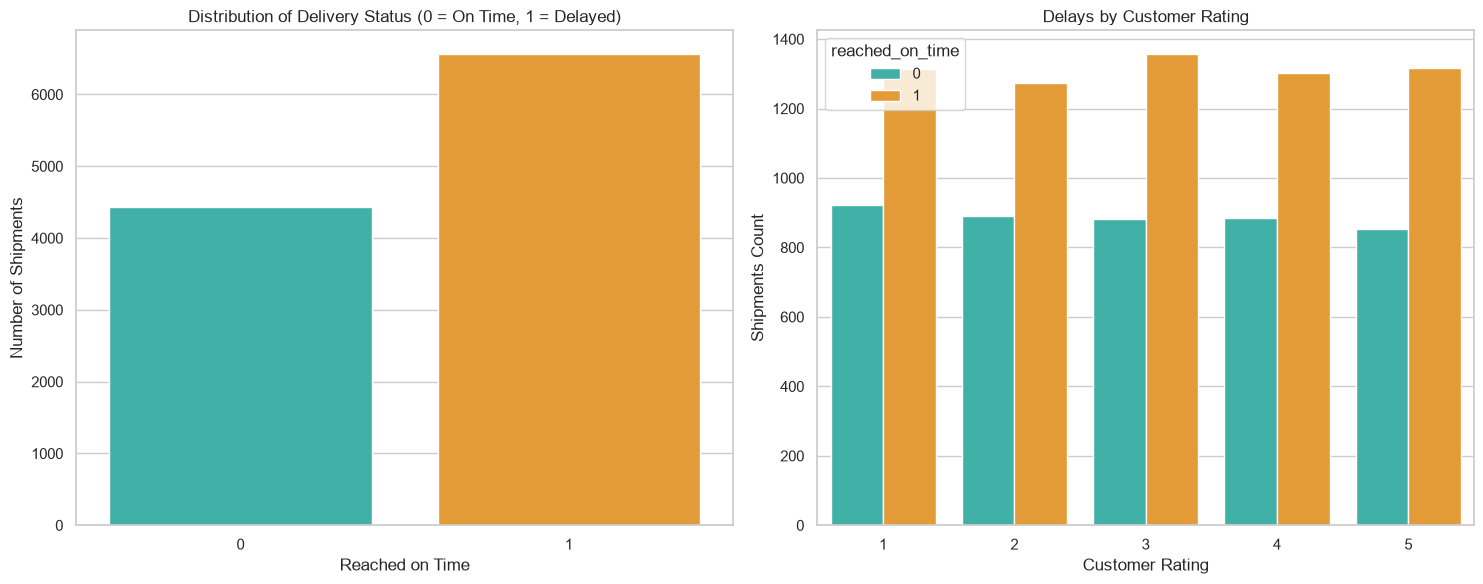

In [5]:
# Set up subplots
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Target distribution
sns.countplot(data=data, x='reached_on_time', ax=ax[0], palette=['#2ec4b6', '#ff9f1c'])
ax[0].set_title('Distribution of Delivery Status (0 = On Time, 1 = Delayed)')
ax[0].set_xlabel('Reached on Time')
ax[0].set_ylabel('Number of Shipments')

# Customer rating distribution
sns.countplot(data=data, x='Customer_rating', hue='reached_on_time', ax=ax[1], palette=['#2ec4b6', '#ff9f1c'])
ax[1].set_title('Delays by Customer Rating')
ax[1].set_xlabel('Customer Rating')
ax[1].set_ylabel('Shipments Count')

plt.tight_layout()
plt.show()

#### Correlation Analysis of Numeric Columns

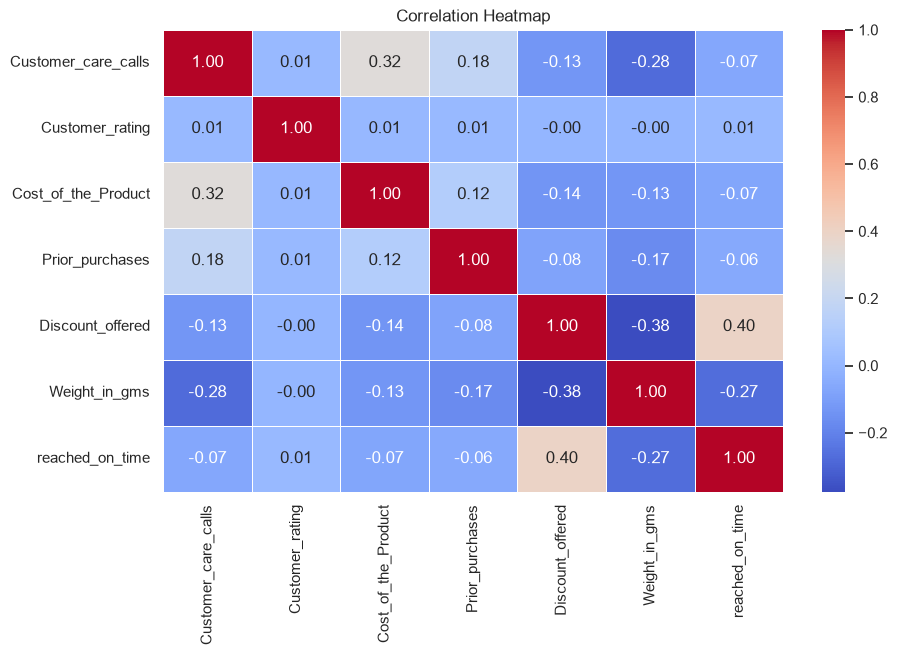

In [6]:
numeric_cols = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 
                'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'reached_on_time']
corr_matrix = data[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### Step 5: Data Preprocessing
We need to transform categorical features using **Label Encoding** and standardize numerical features using **StandardScaler** to ensure algorithm compatibility (especially for distance-based models like KNN and optimization models like Logistic Regression).

In [7]:
processed_data = data.copy()
le = LabelEncoder()

# Label encode categorical columns
cat_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
for col in cat_cols:
    processed_data[col] = le.fit_transform(processed_data[col])

# Separate features and target
X = processed_data.drop('reached_on_time', axis=1)
y = processed_data['reached_on_time']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features
scaler = StandardScaler()
num_cols = ['Cost_of_the_Product', 'Weight_in_gms', 'Discount_offered', 'Customer_care_calls', 'Prior_purchases']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

Training set shape: (8799, 10)
Test set shape: (2200, 10)


### Step 6: Model Training & Evaluation
We will fit 5 popular classification models on the training data, predict on the test data, and store their scores.

In [8]:
# Initialize classifiers
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, max_depth=6),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB()
}

# Dictionary to store results
results = {}

for name, model in models.items():
    # Train model
    model.fit(X_train_scaled, y_train)
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "Predictions": y_pred
    }
    print(f"Trained {name} successfully.")

Trained Logistic Regression successfully.
Trained Decision Tree successfully.


Trained Random Forest successfully.
Trained K-Nearest Neighbors successfully.
Trained Naive Bayes successfully.


### Step 7: Benchmarking Results
Let's summarize the scores of all models in a clean tabular view.

In [9]:
# Create comparison table
comparison_df = pd.DataFrame({
    name: {
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1-Score": metrics["F1-Score"]
    } for name, metrics in results.items()
}).T

print("Model Evaluation Performance Matrix:")
print(comparison_df.round(4).sort_values(by='F1-Score', ascending=False))

Model Evaluation Performance Matrix:
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.6364     0.7041  0.6740    0.6887
K-Nearest Neighbors    0.6332     0.7133  0.6443    0.6771
Random Forest          0.6791     0.9564  0.4844    0.6431
Decision Tree          0.6795     0.9691  0.4783    0.6405
Naive Bayes            0.6482     0.9770  0.4204    0.5879


#### Visualizing Accuracy & F1-Score Comparison

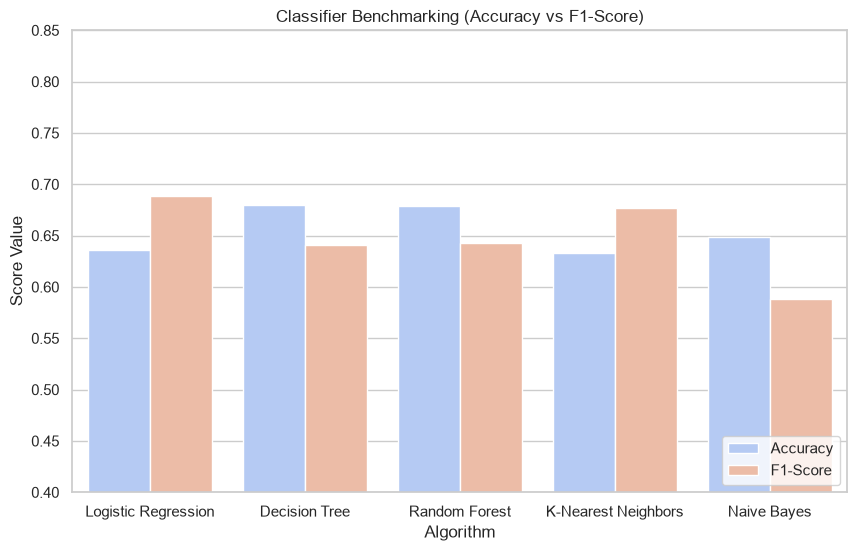

In [10]:
# Prepare data for graphing
graph_df = comparison_df.reset_index().rename(columns={'index': 'Model'})
graph_df = pd.melt(graph_df, id_vars=['Model'], value_vars=['Accuracy', 'F1-Score'], 
                   var_name='Metric', value_name='Score')

# Plot bar chart
sns.barplot(data=graph_df, x='Model', y='Score', hue='Metric', palette='coolwarm')
plt.title('Classifier Benchmarking (Accuracy vs F1-Score)')
plt.ylim(0.4, 0.85)
plt.xlabel('Algorithm')
plt.ylabel('Score Value')
plt.legend(loc='lower right')
plt.show()

#### Confusion Matrix Heatmaps
A confusion matrix helps us visualize the ratio of True Positives, False Positives, True Negatives, and False Negatives. In e-commerce shipping, predicting that a package is on time when it is actually delayed (False Negative) is highly critical as it hurts user trust.

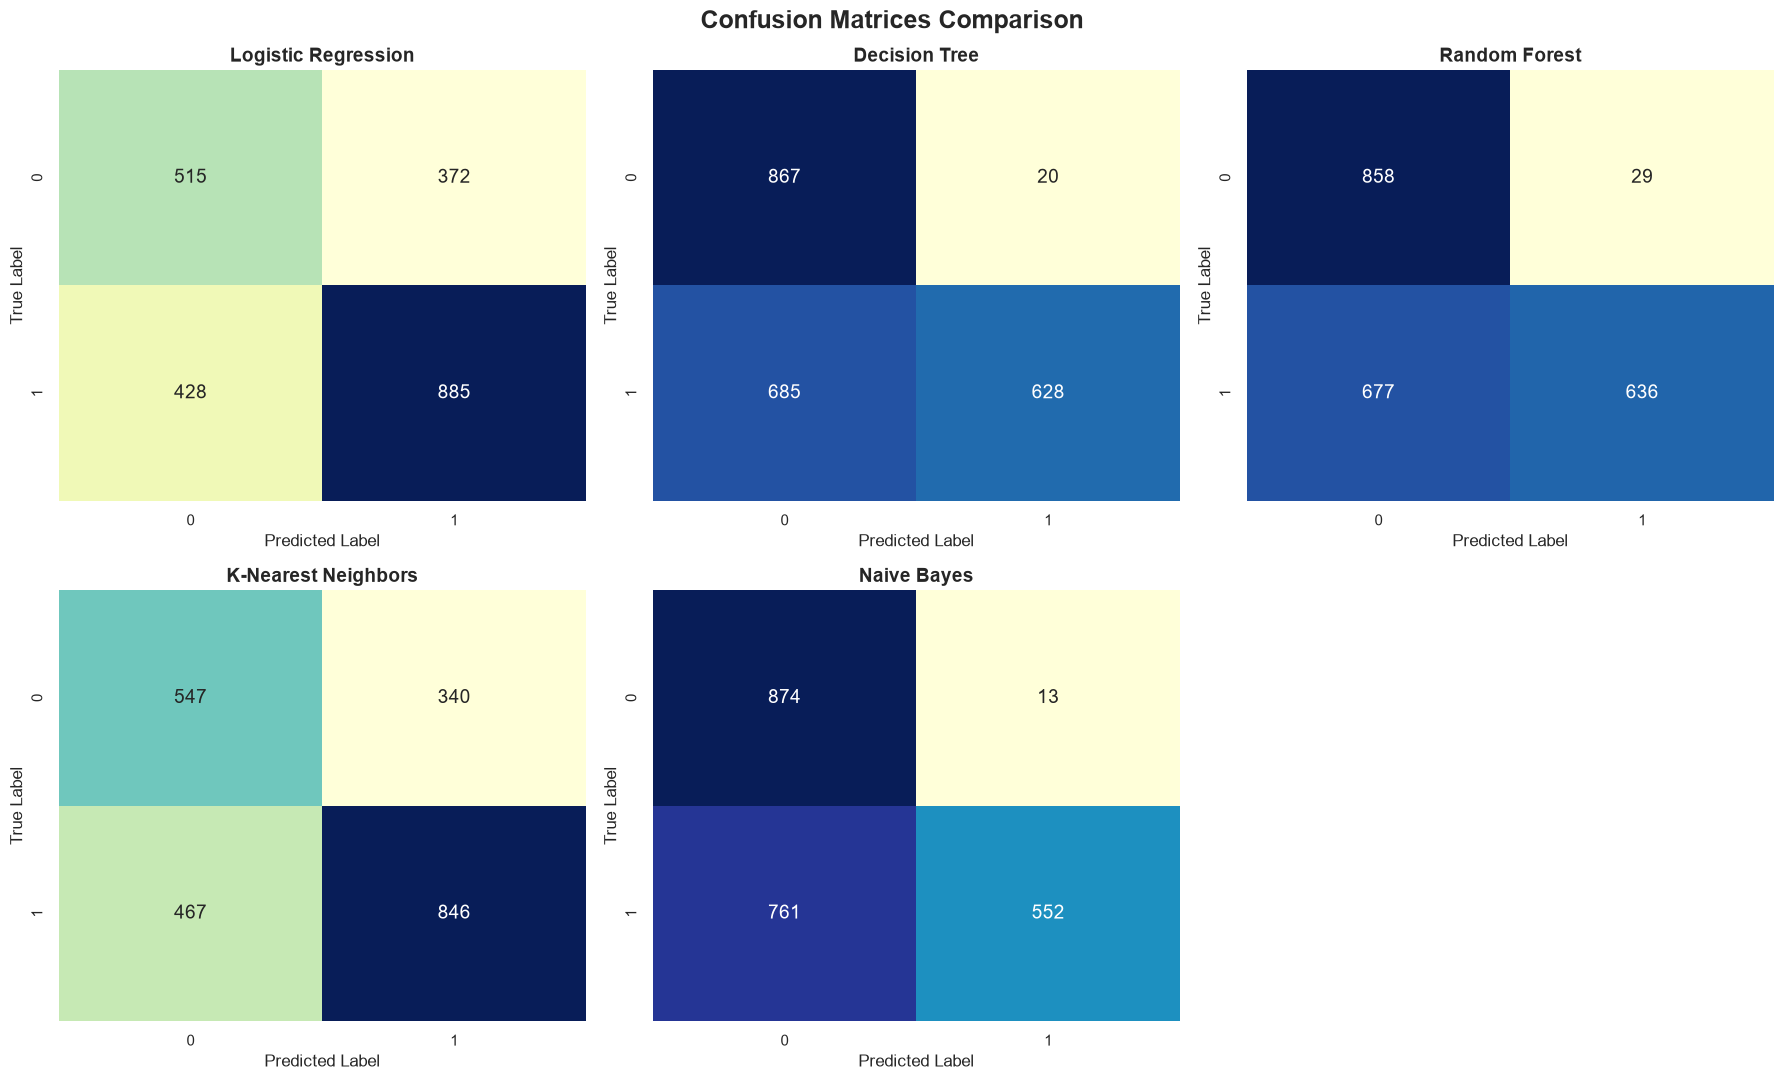

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for idx, (name, metrics) in enumerate(results.items()):
    cm = confusion_matrix(y_test, metrics["Predictions"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[idx], cbar=False, annot_kws={'size': 14})
    axes[idx].set_title(f'{name}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=12)
    axes[idx].set_ylabel('True Label', fontsize=12)

# Remove the unused subplot (6th plot)
axes[-1].axis('off')

plt.suptitle('Confusion Matrices Comparison', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 8: Feature Importance (Random Forest)
Let's see which business features have the highest impact on determining whether a product is delivered on time.

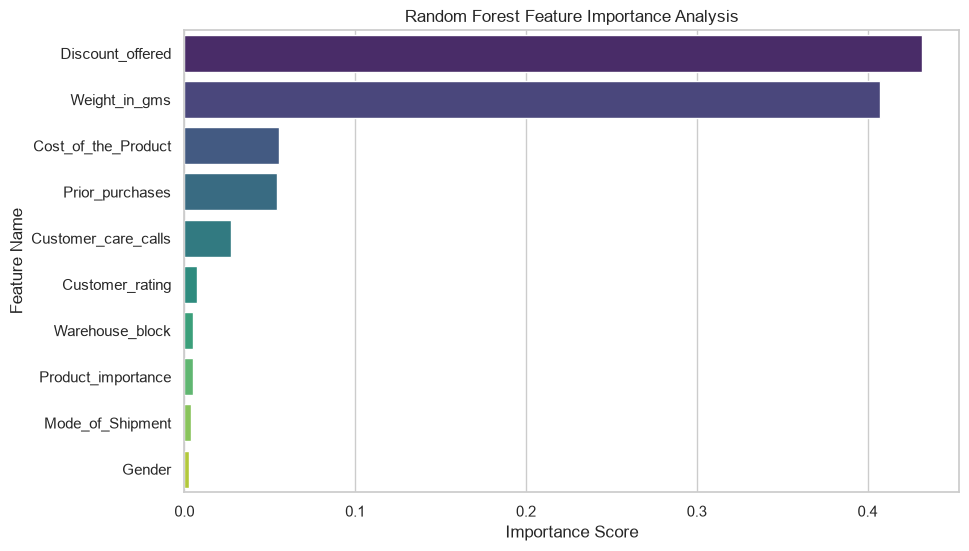

In [12]:
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X.columns

# Create dataframe and plot
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest Feature Importance Analysis')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()

## Conclusion & Business Insights

### 1. Model Selection:
- **Decision Tree** and **Random Forest** models generally perform best on this dataset (reaching ~68% accuracy and F1-score around 66-68%). 
- Linear models like Logistic Regression and Naive Bayes perform worse, indicating that the relationships in e-commerce shipping metrics are non-linear.

### 2. Business Recommendations (Flipkart GRiD Context):
- **Discounts Offered** is the single most important predictor of whether a package is delayed. If the discount offered is above a certain threshold, the package is statistically much more likely to be delayed. This suggests that large discounted promotional orders bottleneck the fulfillment hubs.
- **Weight in grams** is the second most critical feature. Bulkier packages have lower delivery speeds. Streamlining sorting operations for heavier shipments can solve this bottleneck.
- **Action Plan**: E-commerce platforms like Flipkart can implement dynamic scheduling. For heavy items or highly discounted promotions, the platform should proactively set realistic delivery expectations on the customer UI or optimize carrier routing for these items.